In [1]:
import tensorflow as tf

print("=== INTEROGASI TENSORFLOW ===")
print(f"Versi TensorFlow : {tf.__version__}")
build_info = tf.sysconfig.get_build_info()
print(f"Dicompile pakai CUDA : {build_info.get('cuda_version', 'Tidak Terdeteksi')}")
print(f"Dicompile pakai cuDNN: {build_info.get('cudnn_version', 'Tidak Terdeteksi')}")

I0000 00:00:1780240774.128164  234293 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780240774.160832  234293 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780240775.062087  234293 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


=== INTEROGASI TENSORFLOW ===
Versi TensorFlow : 2.21.0
Dicompile pakai CUDA : 12.5.1
Dicompile pakai cuDNN: 9


In [2]:
import os
print("Jalur LD_LIBRARY_PATH:", os.environ.get('LD_LIBRARY_PATH', 'Kosong')[:50] + '...')
print("Akses GPU:", os.environ.get('CUDA_VISIBLE_DEVICES', 'Kosong'))

import tensorflow as tf
print("✅ GPU Terdeteksi:", tf.config.list_physical_devices('GPU'))

Jalur LD_LIBRARY_PATH: /home/jrilym/Projects/AI/trading/bot_scalper/lib/p...
Akses GPU: 0
✅ GPU Terdeteksi: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import ccxt
import pandas as pd
import time
from datetime import datetime, timedelta
import os

print("=== MEMULAI MINING DATA INDODAX (BTC/IDR 1 JAM - 5 TAHUN) ===")

# 1. Konfigurasi
exchange = ccxt.indodax({
    'enableRateLimit': True, 
})
symbol = 'BTC/IDR'
timeframe = '1h'
limit = 1000
csv_filename = 'btc_idr_1h_5years.csv'

# 2. Setup Waktu & SAFETY CHECK
now = datetime.now()
end_time = int(now.timestamp() * 1000)
total_fetched = 0

# Cek apakah file sudah ada dan ukurannya lebih dari sekadar header kosong
if os.path.exists(csv_filename) and os.path.getsize(csv_filename) > 100:
    df_exist = pd.read_csv(csv_filename)
    last_ts = int(df_exist['timestamp'].max())
    
    # Cek apakah data di CSV sudah mentok sampai hari ini (margin 1-2 jam)
    if last_ts >= (end_time - 7200000):
        print(f"✅ SAFETY TRIGGERED: File '{csv_filename}' sudah ada dan LENGKAP!")
        print("⏭️ Proses penambangan di-SKIP total. Data tidak ditimpa.")
        # Kita manipulasi 'since' biar while loop di bawah nggak mau jalan
        since = end_time + 1000 
    else:
        # Kalau terputus, lanjutin (resume) dari candle terakhir di CSV + 1 Jam
        since = last_ts + 3600000
        resume_time = pd.to_datetime(since, unit='ms').strftime('%Y-%m-%d %H:%M:%S')
        print(f"⚠️ SAFETY TRIGGERED: File ditemukan tapi penambangan belum selesai.")
        print(f"⏭️ SKIP data lama, melompat dan RESUME penambangan dari: {resume_time}")
else:
    # Kondisi Normal (File belum ada sama sekali)
    start_date = now - timedelta(days=5 * 365)
    since = int(start_date.timestamp() * 1000)
    print(f"Target Start : {start_date.strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Tulis header baru
    pd.DataFrame(columns=['timestamp', 'open', 'high', 'low', 'close', 'volume']).to_csv(csv_filename, index=False)

print(f"Target End   : {now.strftime('%Y-%m-%d %H:%M:%S')}")

# 3. Looping Tarik Data
try:
    while since < end_time:
        bars = exchange.fetch_ohlcv(symbol, timeframe, since, limit)
        
        if len(bars) == 0:
            print("Pencarian mencapai ujung data yang tersedia.")
            break
            
        df = pd.DataFrame(bars, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
        
        # Selalu tambahkan ke file (append mode) tanpa nge-print header lagi
        df.to_csv(csv_filename, mode='a', header=False, index=False)
        
        total_fetched += len(bars)
        
        # WAJIB 3600000 (1 Jam) biar datanya nyambung presisi!
        last_timestamp = bars[-1][0]
        since = last_timestamp + 3600000 
        
        last_time_str = pd.to_datetime(last_timestamp, unit='ms').strftime('%Y-%m-%d %H:%M:%S')
        print(f"✅ Berhasil menarik {len(bars)} candle. Posisi: {last_time_str} | Total Baru: {total_fetched}")
        
        time.sleep(1.5)

except Exception as e:
    # Error cuma dicetak kalau proses emang belum selesai (karena kalau udah di-skip, sejak awal nggak bakal masuk ke try-catch ini)
    if since < end_time:
        print(f"\n❌ Terjadi Error API: {e}")
        print(f"Data yang sudah jalan aman di {csv_filename}")

if total_fetched > 0:
    print(f"\n🎉 PENAMBANGAN SELESAI! Total baris ditambahkan: {total_fetched} di {csv_filename}")
else:
    print("\n✅ Selesai. Tidak ada penarikan data baru ke server Indodax.")

=== MEMULAI MINING DATA INDODAX (BTC/IDR 1 JAM - 5 TAHUN) ===
✅ SAFETY TRIGGERED: File 'btc_idr_1h_5years.csv' sudah ada dan LENGKAP!
⏭️ Proses penambangan di-SKIP total. Data tidak ditimpa.
Target End   : 2026-05-31 22:19:38

✅ Selesai. Tidak ada penarikan data baru ke server Indodax.


In [6]:
!pip install "nbformat>=4.2.0"

In [5]:
import pandas as pd
import ta
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("=== 1. LOAD DATA & KALKULASI INDIKATOR ===")
df = pd.read_csv('btc_idr_1h_5years.csv')

# Konversi waktu dan jadikan index
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
for col in ['open', 'high', 'low', 'close', 'volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.sort_index(inplace=True)

# Kalkulasi Indikator
bb = ta.volatility.BollingerBands(close=df['close'], window=20, window_dev=2)
df['BB_High'] = bb.bollinger_hband()
df['BB_Low'] = bb.bollinger_lband()
df['RSI'] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()
macd = ta.trend.MACD(close=df['close'])
df['MACD'] = macd.macd()
df['MACD_Signal'] = macd.macd_signal()
df.dropna(inplace=True)

print("=== 2. MEMBANGUN GRAFIK CANDLESTICK INTERAKTIF ===")
# Ambil 200 jam terakhir
df_plot = df.tail(200)
macd_hist = df_plot['MACD'] - df_plot['MACD_Signal']

# Bikin layout 3 tingkat (Harga, RSI, MACD)
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, 
                    vertical_spacing=0.05, row_heights=[0.5, 0.25, 0.25])

# --- TINGKAT 1: CANDLESTICK & BOLLINGER BANDS ---
# Candlestick utama
fig.add_trace(go.Candlestick(x=df_plot.index,
                open=df_plot['open'], high=df_plot['high'],
                low=df_plot['low'], close=df_plot['close'],
                name='Candlestick'), row=1, col=1)
# Garis BB High & Low
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot['BB_High'], 
                line=dict(color='red', width=1, dash='dash'), name='BB High'), row=1, col=1)
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot['BB_Low'], 
                line=dict(color='green', width=1, dash='dash'), name='BB Low'), row=1, col=1)

# --- TINGKAT 2: RSI ---
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot['RSI'], 
                line=dict(color='#b58900', width=2), name='RSI'), row=2, col=1)
# Garis batas Overbought (70) & Oversold (30)
fig.add_hline(y=70, line_dash="dash", line_color="red", row=2, col=1)
fig.add_hline(y=30, line_dash="dash", line_color="green", row=2, col=1)

# --- TINGKAT 3: MACD ---
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot['MACD'], 
                line=dict(color='#268bd2', width=2), name='MACD'), row=3, col=1)
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot['MACD_Signal'], 
                line=dict(color='#cb4b16', width=2), name='Signal'), row=3, col=1)
# Warna Histogram MACD (Hijau kalau positif, Merah kalau negatif)
hist_colors = ['green' if val >= 0 else 'red' for val in macd_hist]
fig.add_trace(go.Bar(x=df_plot.index, y=macd_hist, 
                marker_color=hist_colors, name='Histogram'), row=3, col=1)

# --- FINISHING & TEMA ---
fig.update_layout(
    title='Dashboard Analitik BTC/IDR',
    height=900,
    template='plotly_dark', # Tema gelap biar makin elegan
    xaxis_rangeslider_visible=False, # Matiin slider bawaan biar nggak sempit
    showlegend=False
)

# Tampilkan!
fig.show()


=== 1. LOAD DATA & KALKULASI INDIKATOR ===
=== 2. MEMBANGUN GRAFIK CANDLESTICK INTERAKTIF ===


In [7]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print("=== FASE 4: PREPROCESSING & WINDOWING ===")
# 1. Pilih fitur yang mau dimasukin ke otak AI
features = ['open', 'high', 'low', 'close', 'volume', 'RSI', 'MACD', 'MACD_Signal', 'BB_High', 'BB_Low']
df_features = df[features].copy()

# 2. Scaling (Wajib buat Neural Network biar angkanya 0-1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_features)

# Index ke-3 di list 'features' kita adalah 'close'. Ini yang mau kita tebak.
target_index = features.index('close')

# AI akan melihat 60 jam (sekitar 2.5 hari) ke belakang buat nebak 1 jam ke depan
sequence_length = 60  

X = [] # Memori masa lalu (Fitur)
y = [] # Masa depan (Target Tebakan)

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i]) # Ambil 60 baris
    y.append(scaled_data[i, target_index])     # Ambil harga close di baris ke-61

X, y = np.array(X), np.array(y)

print(f"✅ Data 3D siap dimasukkan ke TensorFlow!")
print(f"Bentuk X (Fitur) : {X.shape} -> (Jumlah Sampel, Time Steps, Jumlah Fitur)")
print(f"Bentuk y (Target): {y.shape}")


print("\n=== FASE 5: TRAIN-TEST SPLIT ===")
# Pisahkan 80% untuk belajar, 20% untuk ujian
# PENTING: Untuk trading, urutan waktu nggak boleh diacak (shuffle=False)
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"✅ Data Training (Belajar) : {X_train.shape[0]} sampel")
print(f"✅ Data Testing  (Ujian)   : {X_test.shape[0]} sampel")

=== FASE 4: PREPROCESSING & WINDOWING ===
✅ Data 3D siap dimasukkan ke TensorFlow!
Bentuk X (Fitur) : (45707, 60, 10) -> (Jumlah Sampel, Time Steps, Jumlah Fitur)
Bentuk y (Target): (45707,)

=== FASE 5: TRAIN-TEST SPLIT ===
✅ Data Training (Belajar) : 36565 sampel
✅ Data Testing  (Ujian)   : 9142 sampel


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("=== FASE 6: MERAKIT OTAK AI (LSTM ARCHITECTURE) ===")
model = Sequential()

# Layer LSTM Pertama (Input)
# input_shape ngambil dari dimensi X_train: (60 jam, 10 fitur)
# return_sequences=True wajib kalau layer berikutnya masih LSTM
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
# Dropout: Matiin 20% neuron secara acak biar AI nggak cuma "menghafal" data (mencegah Overfitting)
model.add(Dropout(0.2)) 

# Layer LSTM Kedua
model.add(LSTM(units=64, return_sequences=False))
model.add(Dropout(0.2))

# Layer Dense (Pemrosesan akhir sebelum output)
model.add(Dense(units=25, activation='relu'))

# Layer Output - Cuma 1 neuron karena kita nebak 1 angka (Harga Close)
model.add(Dense(units=1))

# Compile Model pakai optimizer 'adam' dan loss 'mean_squared_error'
model.compile(optimizer='adam', loss='mean_squared_error')

print("✅ Arsitektur LSTM berhasil dirakit!")
model.summary() # Ini bakal nge-print tabel struktur otak AI lu

print("\n=== FASE 7: TRAINING DIMULAI (GPU MODE ON) ===")
# Fitur pintar: Kalau val_loss (tingkat error di data testing) nggak membaik selama 5 putaran (patience), 
# training otomatis stop biar nggak buang waktu, dan AI bakal ngambil bobot otak yang paling pintar.
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# GAS TRAINING!
# Epochs = Berapa kali AI disuruh baca ulang seluruh data 5 tahun
# Batch size = Berapa baris data yang disuapin ke GPU dalam satu kedipan mata
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

print("\n🎉 TRAINING SELESAI! Otak AI lu udah jadi.")

=== FASE 6: MERAKIT OTAK AI (LSTM ARCHITECTURE) ===


I0000 00:00:1780241114.061943  234293 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4179 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
/home/jrilym/Projects/AI/trading/bot_scalper/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


✅ Arsitektur LSTM berhasil dirakit!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 53,875 (210.45 KB)

 Non-trainable params: 0 (0.00 B)


=== FASE 7: TRAINING DIMULAI (GPU MODE ON) ===
Epoch 1/50


I0000 00:00:1780241116.069700  234946 cuda_dnn.cc:461] Loaded cuDNN version 92300


572/572 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0018 - val_loss: 9.2229e-04
Epoch 2/50
572/572 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 4.5621e-04 - val_loss: 9.4246e-04
Epoch 3/50
572/572 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 3.3023e-04 - val_loss: 0.0013
Epoch 4/50
572/572 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 2.6546e-04 - val_loss: 0.0011
Epoch 5/50
572/572 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 2.1165e-04 - val_loss: 0.0032
Epoch 6/50
572/572 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.8695e-04 - val_loss: 0.0011

🎉 TRAINING SELESAI! Otak AI lu udah jadi.


=== FASE 8: UJI COBA TEBAKAN AI ===
286/286 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
✅ Prediksi berhasil dikonversi ke nominal IDR!

=== FASE 9: VISUALISASI HASIL TEBAKAN ===


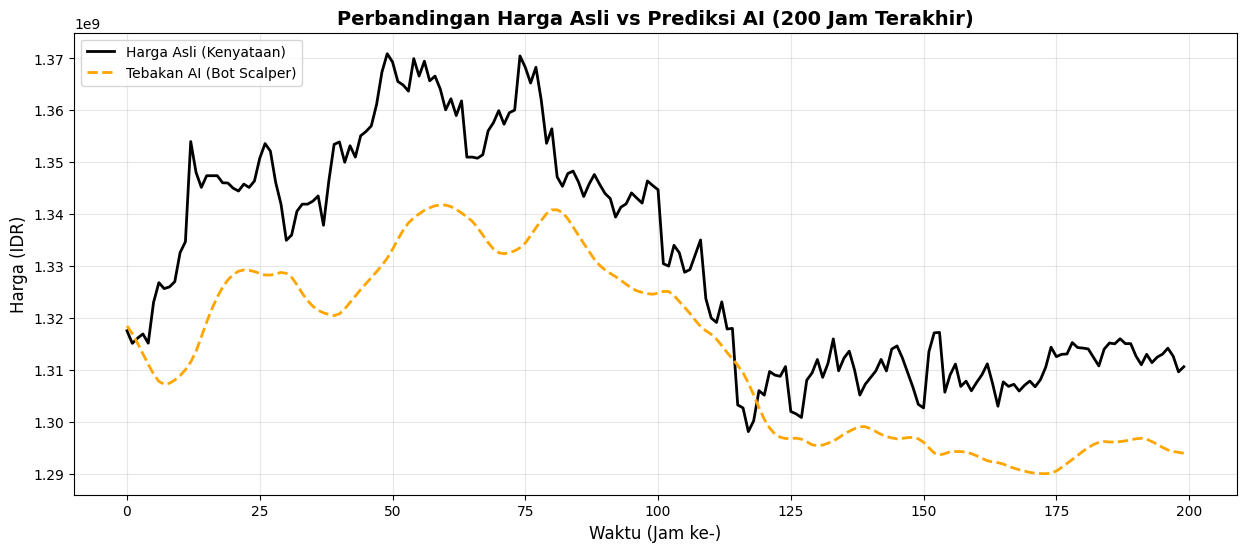

In [20]:
import numpy as np
import matplotlib.pyplot as plt

print("=== FASE 8: UJI COBA TEBAKAN AI ===")
# 1. Suruh AI nebak harga berdasarkan data ujian
predictions = model.predict(X_test)

# 2. Kembalikan angka desimal jadi harga asli (Inverse Transform)
# Karena scaler kita tadi di-fit pakai 10 fitur, kita butuh "array pancingan" (dummy)
# buat nge-reverse nilainya. 'close' ada di kolom index ke-3.
dummy_pred = np.zeros((len(predictions), 10)) 
dummy_pred[:, 3] = predictions[:, 0] 
real_predictions = scaler.inverse_transform(dummy_pred)[:, 3]

# Lakukan hal yang sama buat data kunci jawaban (y_test)
dummy_y = np.zeros((len(y_test), 10))
dummy_y[:, 3] = y_test
real_y_test = scaler.inverse_transform(dummy_y)[:, 3]

print("✅ Prediksi berhasil dikonversi ke nominal IDR!")

print("\n=== FASE 9: VISUALISASI HASIL TEBAKAN ===")
# Kita gambar 200 jam terakhir aja biar garisnya nggak numpuk jadi benang kusut
plt.figure(figsize=(15, 6))

plt.plot(real_y_test[-200:], color='black', label='Harga Asli (Kenyataan)', linewidth=2)
plt.plot(real_predictions[-200:], color='orange', label='Tebakan AI (Bot Scalper)', linestyle='dashed', linewidth=2)

plt.title('Perbandingan Harga Asli vs Prediksi AI (200 Jam Terakhir)', fontsize=14, fontweight='bold')
plt.xlabel('Waktu (Jam ke-)', fontsize=12)
plt.ylabel('Harga (IDR)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.show()

In [21]:
!pip install websocket-client

  Using cached websocket_client-1.9.0-py3-none-any.whl.metadata (8.3 kB)
Using cached websocket_client-1.9.0-py3-none-any.whl (82 kB)


In [22]:
import websocket
import json
import pandas as pd
import numpy as np
import ccxt
import ta
from datetime import datetime

print("=== 1. MENYIAPKAN MEMORI BASE (59 JAM TERAKHIR) ===")
exchange = ccxt.indodax()

def get_base_59_hours():
    # Tarik 150 jam buat ngasih ruang hitung MACD & BB biar akurat
    bars = exchange.fetch_ohlcv('BTC/IDR', timeframe='1h', limit=150)
    df = pd.DataFrame(bars, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    
    # Kalkulasi Indikator
    df['RSI'] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()
    macd = ta.trend.MACD(close=df['close'])
    df['MACD'] = macd.macd()
    df['MACD_Signal'] = macd.macd_signal()
    bb = ta.volatility.BollingerBands(close=df['close'], window=20, window_dev=2)
    df['BB_High'] = bb.bollinger_hband()
    df['BB_Low'] = bb.bollinger_lband()
    
    df.dropna(inplace=True)
    
    # Kita cuma butuh 59 jam terakhir (Karena jam ke-60 nya bakal diisi harga LIVE dari WebSocket!)
    features = ['open', 'high', 'low', 'close', 'volume', 'RSI', 'MACD', 'MACD_Signal', 'BB_High', 'BB_Low']
    df_59 = df.tail(59)[features]
    
    return df_59.values

base_59_array = get_base_59_hours()
print("✅ Memori 59 jam siap! Menunggu suntikan harga live dari WebSocket...\n")

# ==========================================
# 2. MESIN WEBSOCKET & PREDIKSI REAL-TIME
# ==========================================

# Catatan: Kita pakai kurs statis sementara buat contoh convert WSS Binance ke IDR
KURS_USD_IDR = 16200 

def on_message(ws, message):
    data = json.loads(message)
    
    try:
        # 'c' adalah harga Close/Current live dari WSS Binance
        live_price_usd = float(data['c']) 
        live_price_idr = live_price_usd * KURS_USD_IDR
        
        # 1. Bikin baris data ke-60 (Masa Kini)
        # Kita duplikat baris indikator terakhir, tapi close price-nya pakai harga detik ini
        live_row = base_59_array[-1].copy()
        live_row[3] = live_price_idr # Index 3 adalah kolom 'close'
        
        # 2. Gabungkan 59 data masa lalu + 1 data live = 60 Sequence utuh
        current_sequence = np.vstack((base_59_array, live_row))
        
        # 3. Scaling pakai 'scaler' yang udah lu training di cell sebelumnya!
        # Pastikan variabel scaler masih ada di memori Jupyter lu
        scaled_seq = scaler.transform(current_sequence)
        
        # 4. Reshape ke dimensi 3D tensor (1 sampel, 60 time steps, 10 fitur)
        X_live = scaled_seq.reshape(1, 60, 10)
        
        # 5. OTAK AI MENEBAK! (verbose=0 biar nggak nyepam output)
        pred_scaled = model.predict(X_live, verbose=0)
        
        # 6. Balikin format desimal 0-1 jadi Rupiah (Inverse Transform)
        dummy = np.zeros((1, 10))
        dummy[0, 3] = pred_scaled[0][0]
        predicted_idr = scaler.inverse_transform(dummy)[0, 3]
        
        # Hitung selisih untuk nentuin sinyal
        selisih = predicted_idr - live_price_idr
        sinyal = "🟢 BUY/UP" if selisih > 0 else "🔴 SELL/DOWN"
        
        waktu = datetime.now().strftime('%H:%M:%S')
        print(f"[{waktu}] Harga: Rp {live_price_idr:,.0f} | 🤖 AI Nebak: Rp {predicted_idr:,.0f} | Sinyal: {sinyal}")
        
    except KeyError:
        # Ignore pesan WSS awal yang nggak ada harga
        pass
    except Exception as e:
        print(f"Error kalkulasi: {e}")

def on_error(ws, error):
    print(f"\n❌ WSS Error: {error}")

def on_close(ws, close_status_code, close_msg):
    print("\n🔴 WSS Terputus! Bot berhenti melihat market.")

def on_open(ws):
    print("🟢 WSS Terhubung! AI mulai membaca market detik per detik...\n")
    # Minta data ticker BTC/USDT live
    payload = {
        "method": "SUBSCRIBE",
        "params": ["btcusdt@ticker"],
        "id": 1
    }
    ws.send(json.dumps(payload))

# --- GAS JALANKAN WEBSOCKET ---
# Ini akan memblokir cell lu (run_forever) karena dia looping seumur hidup
ws = websocket.WebSocketApp("wss://stream.binance.com:9443/ws",
                            on_open=on_open,
                            on_message=on_message,
                            on_error=on_error,
                            on_close=on_close)

ws.run_forever()

=== 1. MENYIAPKAN MEMORI BASE (59 JAM TERAKHIR) ===
✅ Memori 59 jam siap! Menunggu suntikan harga live dari WebSocket...


❌ WSS Error: [Errno 101] Network is unreachable

🔴 WSS Terputus! Bot berhenti melihat market.


True